In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import train_test_split
from scipy.stats import pearsonr
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
print('ALL okay') #confirmation check

ALL okay


In [2]:
'''
NOTE: All the dataset are uploaded in notebook section privately
Before using, please check for mentioning path.

Here i haven't used another file for test set data but used K cross-fold validation on training set.
'''
# Correct file paths for the Kaggle environment
train_file_path = "C:/Users/kg316/Downloads/gq-implied-volatility-forecasting/ETH_train.csv" 

# other asset data for cross-asset features 
other_asset_train_path ="C:/Users/kg316/Downloads/gq-implied-volatility-forecasting/BTC_train.csv" 

# Load the data
other_asset_df_train = pd.read_csv(other_asset_train_path)
df_train = pd.read_csv(train_file_path)

timestamp_column = 'timestamp'
mid_price_column = 'mid_price'
label_column = 'label'
print('This block is okay') #confirmation check

This block is okay


In [3]:
def engineer_features(df, other_asset_df=None):
    """
    Engineers the requested features on a DataFrame.
    """
    print("Performing feature engineering...")

    # Corrected timestamp conversion and index setting
    df[timestamp_column] = pd.to_datetime(df[timestamp_column])
    df.set_index(timestamp_column, inplace=True)
    
    # Handling missing values (filling them)
    df.fillna(method='ffill', inplace=True)
    df.dropna(inplace=True)
    
    # Rolling Realized Volatility over a 60-second window
    log_returns = np.log(df[mid_price_column] / df[mid_price_column].shift(1))
    df['realized_volatility_60s'] = log_returns.rolling('60s').std() * np.sqrt(365 * 24 * 60*60 )
    df['realized_volatility_10s'] = log_returns.rolling('10s').std() * np.sqrt(365 * 24 * 60*60 )
    
    # Calculating ask-bid spread 
    df['spread1'] = df['ask_price1'] - df['bid_price1'].shift(10) 
    df['spread2'] = df['ask_price2'] - df['bid_price2'].shift(10) 
    df['spread3'] = df['ask_price3'] - df['bid_price3'].shift(10)  
    df['spread4'] = df['ask_price4'] - df['bid_price4'].shift(10) 
    df['spread5'] = df['ask_price5'] - df['bid_price5'].shift(10) 

     # Engineering Weighted Average price
    df['WAP1'] = ((df['ask_price1']* df['bid_volume1'] ) + (df['bid_price1']* df['ask_volume1'] )) / (df['ask_volume1'] + df['bid_volume1']).shift(10) 
    df['WAP2'] = ((df['ask_price2']* df['bid_volume2'] ) + (df['bid_price2']* df['ask_volume2'] )) / (df['ask_volume2'] + df['bid_volume2']).shift(10)  
    df['WAP3'] = ((df['ask_price3']* df['bid_volume3'] ) + (df['bid_price3']* df['ask_volume3'] )) / (df['ask_volume3'] + df['bid_volume3']).shift(10)  
    df['WAP4'] = ((df['ask_price4']* df['bid_volume4'] ) + (df['bid_price4']* df['ask_volume4'] )) / (df['ask_volume4'] + df['bid_volume4']).shift(10)  
    df['WAP5'] = ((df['ask_price5']* df['bid_volume5'] ) + (df['bid_price5']* df['ask_volume5'] )) / (df['ask_volume5'] + df['bid_volume5']).shift(10)  
    
    #Averaged Weighted Average price of all 5 level
    df['AWAP']= df['WAP1'] + df['WAP2']+ df['WAP3']+ df['WAP4']+ df['WAP5'].shift(10) 
    
    # 2. Order-book Imbalance
    df['order_book_imbalance_1'] = (df['bid_volume1'] - df['ask_volume1']) / (df['bid_volume1'] + df['ask_volume1']).shift(10) 
    df['order_book_imbalance_2'] = (df['bid_volume2'] - df['ask_volume2']) / (df['bid_volume2'] + df['ask_volume2']).shift(10) 
    df['order_book_imbalance_3'] = (df['bid_volume3'] - df['ask_volume3']) / (df['bid_volume3'] + df['ask_volume3']).shift(10) 
    df['order_book_imbalance_4'] = (df['bid_volume4'] - df['ask_volume4']) / (df['bid_volume4'] + df['ask_volume4']).shift(10) 
    df['order_book_imbalance_5'] = (df['bid_volume5'] - df['ask_volume5']) / (df['bid_volume5'] + df['ask_volume5']).shift(10) 

    # CReating lagged features (1s, 5s and 10s)
    df['OBI_lagged_1s'] = df['order_book_imbalance_1'].shift(1)
    df['OBI_lagged_5s'] = df['order_book_imbalance_1'].shift(5)
    df['OBI_lagged_10s'] = df['order_book_imbalance_1'].shift(10)
    df['WAP_lagged_1s'] = df['WAP1'].shift(1)
    df['WAP_lagged_5s'] = df['WAP1'].shift(5)
    df['WAP_lagged_10s'] = df['WAP1'].shift(10)
    
    # 3. Cross-Asset Returns
    if other_asset_df is not None:
        other_asset_df[timestamp_column] = pd.to_datetime(other_asset_df[timestamp_column])
        other_asset_df.set_index(timestamp_column, inplace=True)
        other_asset_df.rename(columns={mid_price_column: 'other_asset_mid_price'}, inplace=True)
        df = df.merge(other_asset_df[['other_asset_mid_price']], left_index=True, right_index=True, how='left')
        df.fillna(method='ffill', inplace=True)
        df['other_asset_log_returns'] = np.log(df['other_asset_mid_price'] / df['other_asset_mid_price'].shift(1))
        df['realized_volatility_60s'] = df['other_asset_log_returns'].rolling('60s').std() * np.sqrt(365 * 24 * 60)
        df['lagged_other_asset_Volatility_10s'] = df['realized_volatility_60s'].shift(10)
        df['lagged_other_asset_Volatility_5s'] = df['realized_volatility_60s'].shift(5)
        
    # Dropping NaN value rows after rolling calculation
    df.dropna(inplace=True) 
    
    print("Feature engineering complete.")
    return df

# Apply the feature engineering to both training and test data
df_train = engineer_features(df_train,other_asset_df_train)

Performing feature engineering...


C:\Users\kg316\AppData\Local\Temp\ipykernel_26116\1011386477.py:12: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)
C:\Users\kg316\AppData\Local\Temp\ipykernel_26116\1011386477.py:54: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  other_asset_df[timestamp_column] = pd.to_datetime(other_asset_df[timestamp_column])
C:\Users\kg316\AppData\Local\Temp\ipykernel_26116\1011386477.py:58: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


Feature engineering complete.


In [4]:
# Separate features and target variable for cross validation 
from sklearn.metrics import r2_score
features = [col for col in df_train.columns if col != label_column]
X = df_train[features]
y = df_train[label_column]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42)
print("Feature and target variables are seperated")

Feature and target variables are seperated


In [5]:
# --- Model Training and Walk-Forward Validation ---
print("\nStarting walk-forward cross-validation...")

# Define walk-forward validation with 5 splits
n_splits = 5
tscv = TimeSeriesSplit(n_splits=n_splits) # Using TimeSeriesSplit for proper data splitting in cross validation.

# Initialize the LightGBM model
model = lgb.LGBMRegressor(objective='regression',metric = 'rmse', random_state=42, n_estimators=100, learning_rate=0.023, force_row_wise=True)
# model = LinearRegression()
#Ceatig empty lists to store meaningful data from cross validation 
rmse_scores = []
mae_scores = []
r2_scores = []
pearson_scores =[] #Using pearson coefficient for actual IV v/s predicted IV figuring
all_y_val_folds = [] # actual data in test set 
all_val_preds_folds = [] #predicetd data for test set
for train_index, val_index in tscv.split(X_train):
    X_train_fold, X_val_fold = X_train.iloc[train_index], X_train.iloc[val_index]
    y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]

    #MODEL FITTING 
    model.fit(X_train_fold, y_train_fold)
    val_preds = model.predict(X_val_fold)
    
    # Storing results for this fold
    all_y_val_folds.append(y_val_fold)
    all_val_preds_folds.append(val_preds)

    r2 = r2_score(y_val_fold, val_preds) # Calculating R-squared score
    fold_pearson, _ = pearsonr(y_val_fold, val_preds) 
    print(f"RMSE:{np.sqrt(mean_squared_error(y_val_fold, val_preds))}")  
    print(f"MAE: {mean_absolute_error(y_val_fold, val_preds)}")
    print(f"R2_SCORE: {r2}")
    print(f"Pearson of this fold :{fold_pearson}")

    #Storing Performance metrics for proper understanding of every fold.
    rmse_scores.append(np.sqrt(mean_squared_error(y_val_fold, val_preds)))
    mae_scores.append(mean_absolute_error(y_val_fold, val_preds))
    pearson_scores.append(fold_pearson)
    # r2_scores.append(r2)
    
#DISPLAYING ACTUAL METRICS OVER ALL FOLDS IN CROSS VALIDATION    
print('---- Final Metrics of all the folds----')
print(f"Average Walk-Forward RMSE: {np.mean(rmse_scores):.6f}")
print(f"Average Walk-Forward MAE: {np.mean(mae_scores):.6f}")
print(f"R-squared score for this fold: {r2:.6f}")
print(f"Fold pearson correlation:{np.mean(pearson_scores)}")


Starting walk-forward cross-validation...
[LightGBM] [Info] Total Bins 12495
[LightGBM] [Info] Number of data points in the train set: 166934, number of used features: 49
[LightGBM] [Info] Start training from score 0.000067
RMSE:4.231434721502871e-05
MAE: 3.0245155845161967e-05
R2_SCORE: 0.5791673972701501
Pearson of this fold :0.76774044244811
[LightGBM] [Info] Total Bins 12495
[LightGBM] [Info] Number of data points in the train set: 333865, number of used features: 49
[LightGBM] [Info] Start training from score 0.000067
RMSE:4.240375344009241e-05
MAE: 3.03235848600368e-05
R2_SCORE: 0.5784753109575528
Pearson of this fold :0.7682970603961093
[LightGBM] [Info] Total Bins 12495
[LightGBM] [Info] Number of data points in the train set: 500796, number of used features: 49
[LightGBM] [Info] Start training from score 0.000067
RMSE:4.2207330966431444e-05
MAE: 3.0176016540419686e-05
R2_SCORE: 0.5845475233840357
Pearson of this fold :0.7724752002516615
[LightGBM] [Info] Total Bins 12495
[Lig

In [ ]:
# --- Line Graph: Actual vs. Predicted IV (Last 5000 points of last CV fold) ---
'''
Plotting only on last 5000 rows data since model would be trained better in last fold.
It's best to plot a smaller, continuous segment to see the tracking clearly.
Let's use the actuals and predictions from the final cross-validation fold.
'''

print("\nGenerating line graph for a sample of the validation data...")
last_fold_actuals = all_y_val_folds[-1]
last_fold_preds = pd.Series(all_val_preds_folds[-1], index=last_fold_actuals.index)

# Select the last 5000 data points for a clear plot
points_to_plot = 10000
plot_actuals = last_fold_actuals.tail(points_to_plot)
plot_preds = last_fold_preds.tail(points_to_plot)

# Creating the plot
plt.figure(figsize=(30,10))
plt.plot(plot_actuals.index, plot_actuals, label='Actual IV', color='grey', linewidth=1)
plt.plot(plot_preds.index, plot_preds, label='Predicted IV', color='orange', linestyle='--', linewidth=1.5)

# Declaring plot essential for better clarity
plt.title(f'Actual vs. Predicted Implied Volatility (Last {points_to_plot} Points of Final Validation Fold)')
plt.xlabel('Timestamp')
plt.ylabel('Implied Volatility (Label)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout() # Adjusts plot to prevent labels from overlapping
plt.show()


Generating feature importance plot...


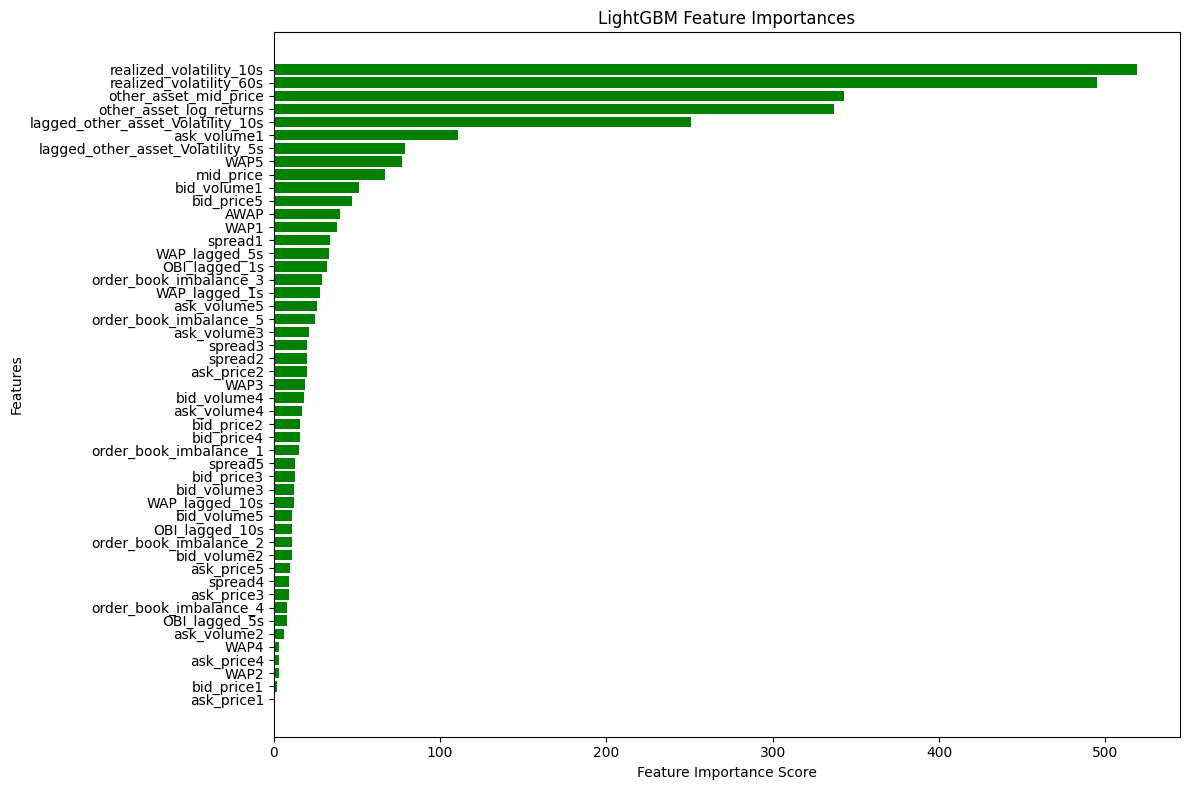


Sorted Feature Importances:
                              Feature  Importance
22            realized_volatility_10s         519
21            realized_volatility_60s         495
45              other_asset_mid_price         343
46            other_asset_log_returns         337
47  lagged_other_asset_Volatility_10s         251
12                        ask_volume1         111
48   lagged_other_asset_Volatility_5s          79
32                               WAP5          77
0                           mid_price          67
2                         bid_volume1          51
9                          bid_price5          47
33                               AWAP          40
28                               WAP1          38
23                            spread1          34
43                      WAP_lagged_5s          33
39                      OBI_lagged_1s          32
36             order_book_imbalance_3          29
42                      WAP_lagged_1s          28
20                   

In [7]:
#--- Feature Importance Calculation and Visualization ---
"""
here we are using feature importance to select only result domanting features. 
Features with higher importance if selected only will result in noise reduction.
we are selecting only top 20 features
"""
print("\nGenerating feature importance plot...")

# Get feature names and their importance scores from the trained model
feature_importances = model.feature_importances_
feature_names = X_train.columns

# Create a DataFrame to store and sort the importance scores
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

# Create a horizontal bar chart to visualize the top features
plt.figure(figsize=(12, 8))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='green')
plt.xlabel('Feature Importance Score')
plt.ylabel('Features')
plt.title('LightGBM Feature Importances')
plt.gca().invert_yaxis()  # Invert the axis to show the most important features at the top
plt.tight_layout()
plt.show()

# You can also print the sorted feature importances
print("\nSorted Feature Importances:")
print(importance_df)

In [8]:
# --- Selecting only Top 5 Features ---
# Creating list of the top 5 feature names from sorted importance_df
top_5_features = importance_df['Feature'].head(5).tolist()

# Declaring future and Target Variables
# X_train =X_train [top_5_features]
# X_test = X_test [top_5_features]
# --- Display the Results ---
print("\nList of the Top 20 Features Selected:")
print(top_5_features)



List of the Top 20 Features Selected:
['realized_volatility_10s', 'realized_volatility_60s', 'other_asset_mid_price', 'other_asset_log_returns', 'lagged_other_asset_Volatility_10s']


In [9]:
print("train set info")
print(X_train.info())

train set info
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1001589 entries, 2024-09-30 15:38:00 to 2024-09-26 11:18:55
Data columns (total 49 columns):
 #   Column                             Non-Null Count    Dtype  
---  ------                             --------------    -----  
 0   mid_price                          1001589 non-null  float64
 1   bid_price1                         1001589 non-null  float64
 2   bid_volume1                        1001589 non-null  float64
 3   bid_price2                         1001589 non-null  float64
 4   bid_volume2                        1001589 non-null  float64
 5   bid_price3                         1001589 non-null  float64
 6   bid_volume3                        1001589 non-null  float64
 7   bid_price4                         1001589 non-null  float64
 8   bid_volume4                        1001589 non-null  float64
 9   bid_price5                         1001589 non-null  float64
 10  bid_volume5                        1001589

In [10]:
# Training Final model 
print('test set info')
print(X_test.info())
model.fit(X_train, y_train)
y_test_pred = model.predict(X_test)
r2 = r2_score(y_test, y_test_pred) # Calculating R-squared score
fold_pearson, _ = pearsonr(y_test, y_test_pred) 
print(f"RMSE:{np.sqrt(mean_squared_error(y_test, y_test_pred))}")  
print(f"MAE: {mean_absolute_error(y_test, y_test_pred)}")
print(f"R2_SCORE: {r2}")
print(f"Pearson of this fold :{fold_pearson}")

test set info
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 250398 entries, 2024-09-27 18:56:47 to 2024-09-27 19:06:00
Data columns (total 49 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   mid_price                          250398 non-null  float64
 1   bid_price1                         250398 non-null  float64
 2   bid_volume1                        250398 non-null  float64
 3   bid_price2                         250398 non-null  float64
 4   bid_volume2                        250398 non-null  float64
 5   bid_price3                         250398 non-null  float64
 6   bid_volume3                        250398 non-null  float64
 7   bid_price4                         250398 non-null  float64
 8   bid_volume4                        250398 non-null  float64
 9   bid_price5                         250398 non-null  float64
 10  bid_volume5                        250398 non-null  floa